# **Importing**

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# **Data Ingestion**

In [2]:
df = pd.read_excel("Data.xlsx")

In [3]:
df

,Gender,Height_cm,Weight_kg,Cholesterol_mg_dL,Diabetes
0,M,161.220174,67.928450,206.674781,0
1,F,161.731196,77.664126,183.204176,0
2,M,167.735211,69.237118,177.087169,0
3,M,173.673655,52.588865,250.254190,0
4,M,179.135846,70.906916,145.829378,0
...,...,...,...,...,...
3995,F,172.689781,91.190359,256.343511,1
3996,F,163.080431,70.586900,293.704972,1
3997,F,181.280569,49.197702,246.745540,1
3998,F,158.272355,85.411336,247.662215,1


In [4]:
df.rename(columns={
    'Gender': 'G',
    'Weight_kg': 'W',
    'Height_cm': 'H',
    'Cholesterol_mg_dL': 'C',
    'Diabetes': 'D'
}, inplace=True)

# View first 5 rows
print(df.head())

   G           H          W           C  D
0  M  161.220174  67.928450  206.674781  0
1  F  161.731196  77.664126  183.204176  0
2  M  167.735211  69.237118  177.087169  0
3  M  173.673655  52.588865  250.254190  0
4  M  179.135846  70.906916  145.829378  0


In [5]:
df.info(),df.shape,

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       4000 non-null   object 
 1   H       4000 non-null   float64
 2   W       4000 non-null   float64
 3   C       4000 non-null   float64
 4   D       4000 non-null   int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 156.4+ KB


(None, (4000, 5))

In [6]:
# Summary statistics for all numeric columns before cleaning and handling outliers
df.describe()

,H,W,C,D
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,168.853053,74.993637,205.017156,0.500000
std,10.014605,14.701123,35.869191,0.500063
min,140.000000,40.000000,100.000000,0.000000
25%,162.097577,64.858194,180.256830,0.000000
50%,168.875944,74.371127,203.428785,0.500000
75%,175.518806,84.696201,228.624803,1.000000
max,209.262377,130.660744,340.011867,1.000000


In [7]:
df.isnull().sum()

,0
G,0
H,0
W,0
C,0
D,0


In [8]:
df.duplicated().sum()

np.int64(0)

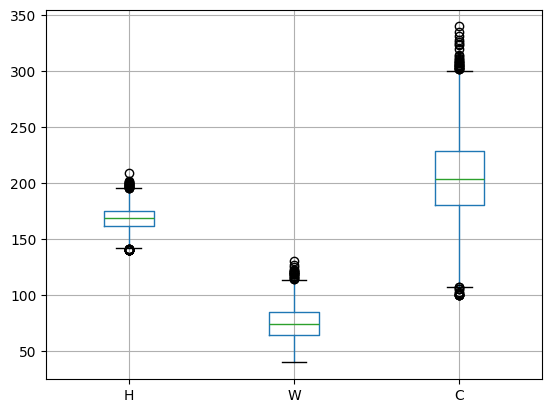

In [9]:
df[['H', 'W', 'C']].boxplot()
plt.show()

In [10]:
# Handling outliers
for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'float32':
        # Calculate IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Clip outliers
        df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

        # Count remaining outliers
        remaining_outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

        print(f"Column '{col}' clipped: lower={lower_limit}, upper={upper_limit}")
        print(f"{col} remaining outliers: {len(remaining_outliers)}")


Column 'H' clipped: lower=141.96573462101296, upper=195.65064857704132
H remaining outliers: 0
Column 'W' clipped: lower=35.10118304655313, upper=114.45321099628595
W remaining outliers: 0
Column 'C' clipped: lower=107.70487191316768, upper=301.17676117753984
C remaining outliers: 0


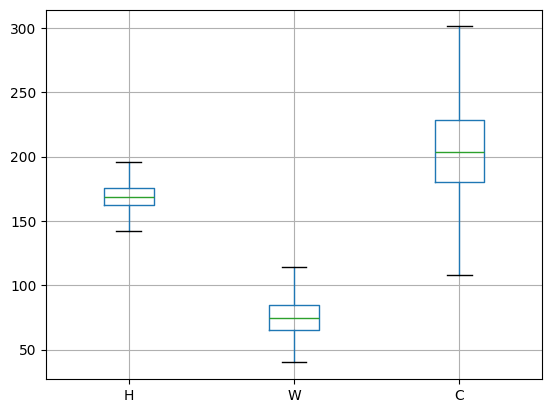

In [11]:
df[['H', 'W', 'C']].boxplot()
plt.show()

In [12]:
# Lable Encoding
encoder = LabelEncoder()
df['G'] = encoder.fit_transform(df['G'])
# View the dataset after encoding and handling outliers
# to ensure consistent training data for machine learning models
df

,G,H,W,C,D
0,1,161.220174,67.928450,206.674781,0
1,0,161.731196,77.664126,183.204176,0
2,1,167.735211,69.237118,177.087169,0
3,1,173.673655,52.588865,250.254190,0
4,1,179.135846,70.906916,145.829378,0
...,...,...,...,...,...
3995,0,172.689781,91.190359,256.343511,1
3996,0,163.080431,70.586900,293.704972,1
3997,0,181.280569,49.197702,246.745540,1
3998,0,158.272355,85.411336,247.662215,1


In [13]:
gender_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
# This ensures (0 = female, 1 = Male).
print("Gender mapping:", gender_mapping)


Gender mapping: {'F': np.int64(0), 'M': np.int64(1)}


# **PMF and CDF Analysis and Visualizations**
---
- Normalizing using Relative Frequency Normalisation or in another words Empirical Probability Normalisation




In [14]:
num_cols = ['C', 'W', 'H']

C: Sum of probabilities = 1.0000
W: Sum of probabilities = 1.0000
H: Sum of probabilities = 1.0000


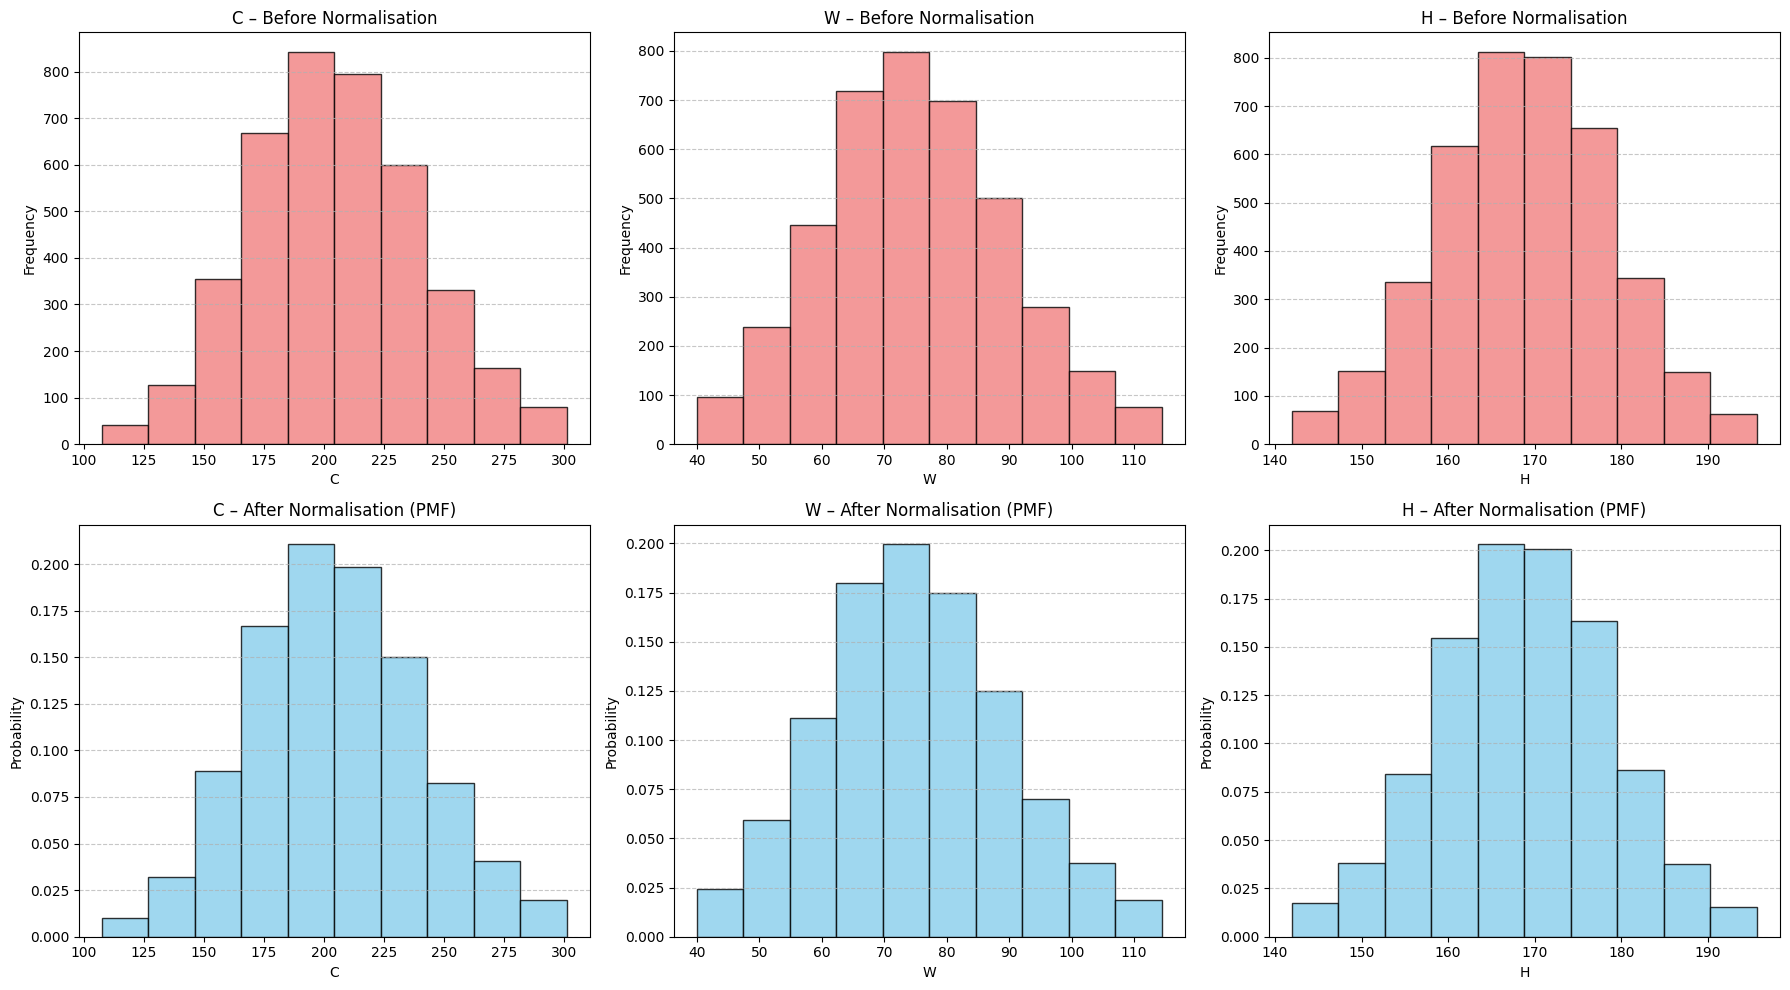

In [15]:
bins = 10

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(num_cols):
    data = df[col].values

    # BEFORE NORMALISATION
    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    ax1 = axes[0, i]
    ax1.bar(bin_centers, counts,
            width=(bin_edges[1] - bin_edges[0]),
            color='lightcoral', edgecolor='black', alpha=0.8)
    ax1.set_title(f'{col} – Before Normalisation', fontsize=12)
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequency')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # AFTER NORMALISATION
    probabilities = counts / counts.sum()

    ax2 = axes[1, i]
    ax2.bar(bin_centers, probabilities,
            width=(bin_edges[1] - bin_edges[0]),
            color='skyblue', edgecolor='black', alpha=0.8)
    ax2.set_title(f'{col} – After Normalisation (PMF)', fontsize=12)
    ax2.set_xlabel(col)
    ax2.set_ylabel('Probability')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    print(f"{col}: Sum of probabilities = {probabilities.sum():.4f}")

plt.tight_layout()
plt.show()


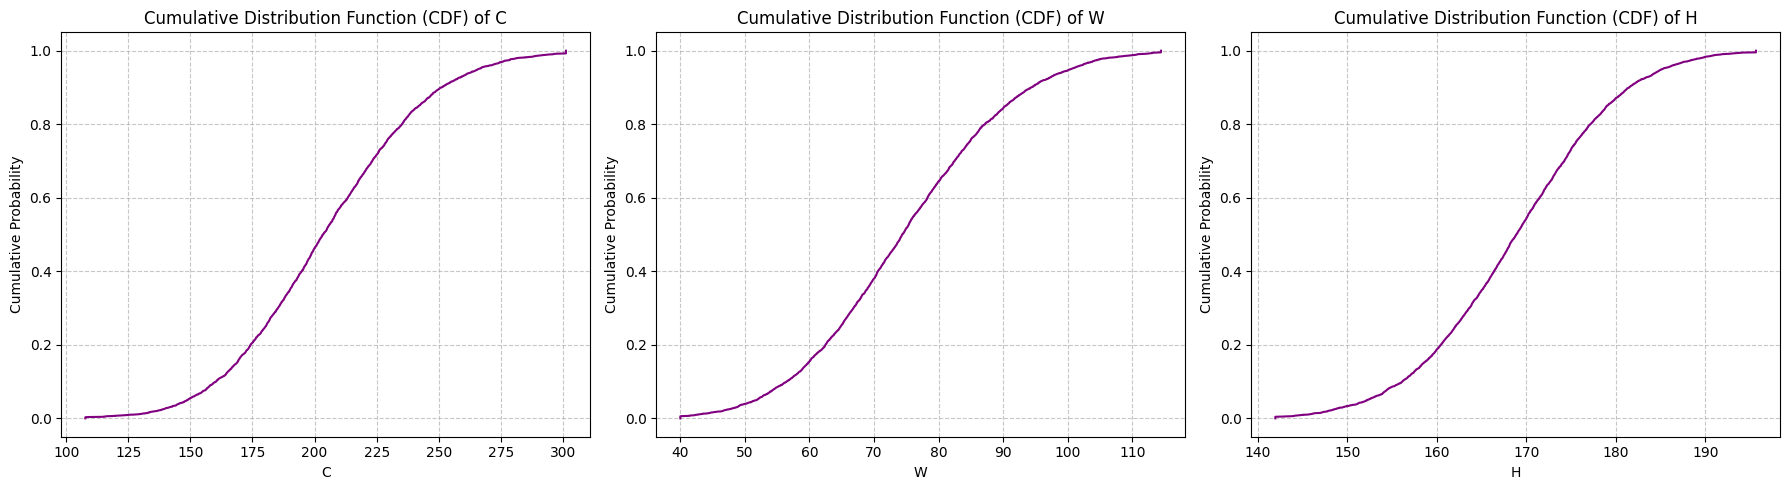

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    data = df[col].dropna().sort_values()
    n = len(data)

    # cumulative probabilities
    x = data
    y = np.arange(1, n + 1) / n

    ax = axes[i]
    ax.plot(x, y, color='purple', linewidth=1.5)

    ax.set_title(f'Cumulative Distribution Function (CDF) of {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Cumulative Probability')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


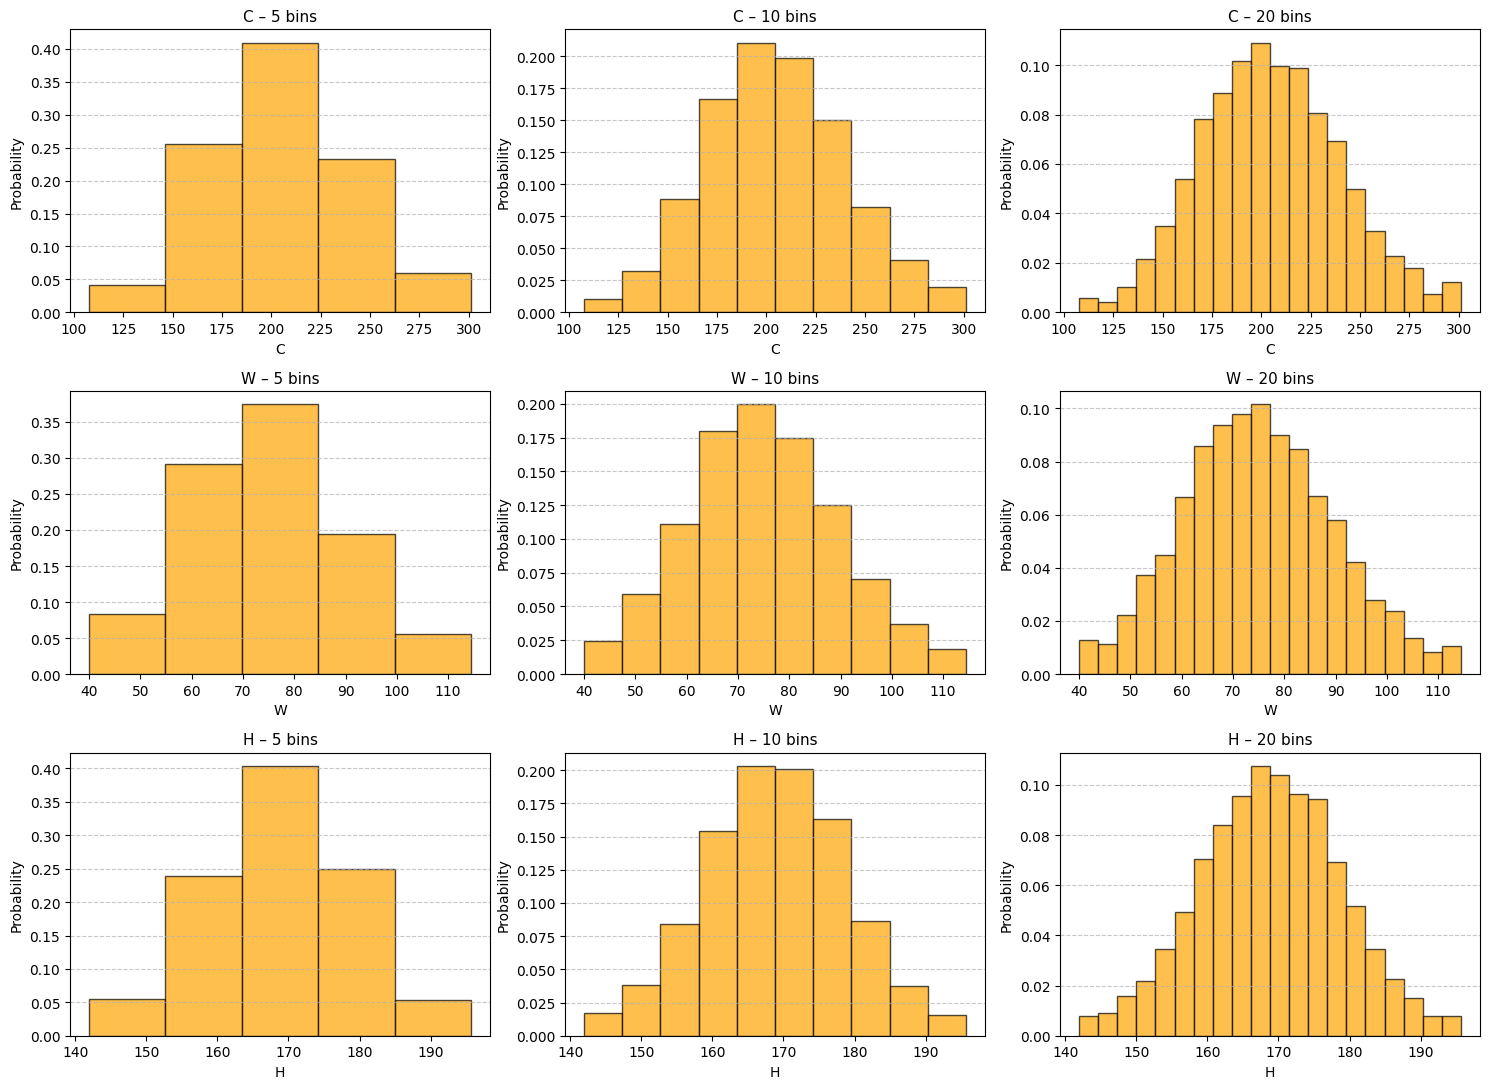

In [17]:
bin_values = [5, 10, 20]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))

for i, col in enumerate(num_cols):
    for j, b in enumerate(bin_values):
        data = df[col].values

        # histogram and normalise for PMF
        counts, bin_edges = np.histogram(data, bins=b)
        probabilities = counts / counts.sum()
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

        ax = axes[i, j]
        ax.bar(bin_centers, probabilities,
               width=(bin_edges[1] - bin_edges[0]),
               color='orange', edgecolor='black', alpha=0.7)

        ax.set_title(f'{col} – {b} bins', fontsize=11)
        ax.set_xlabel(col)
        ax.set_ylabel('Probability')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [18]:
# Determine mean, variance, skewness, kurtosis, for the variables: C, W, H
cols = ['C', 'W', 'H']
for col in cols:
    mean = df[col].mean()
    var = df[col].var()
    skew = df[col].skew()
    kurt = df[col].kurtosis()

    print(f"Statistics for {col}:")
    print(f"  Mean: {mean:.3f}")
    print(f"  Variance: {var:.3f}")
    print(f"  Skewness: {skew:.3f}")
    print(f"  Kurtosis: {kurt:.3f}")
    print("-" * 40)

Statistics for C:
  Mean: 204.947
  Variance: 1265.315
  Skewness: 0.159
  Kurtosis: -0.112
----------------------------------------
Statistics for W:
  Mean: 74.965
  Variance: 213.648
  Skewness: 0.166
  Kurtosis: -0.226
----------------------------------------
Statistics for H:
  Mean: 168.843
  Variance: 98.945
  Skewness: -0.025
  Kurtosis: -0.131
----------------------------------------


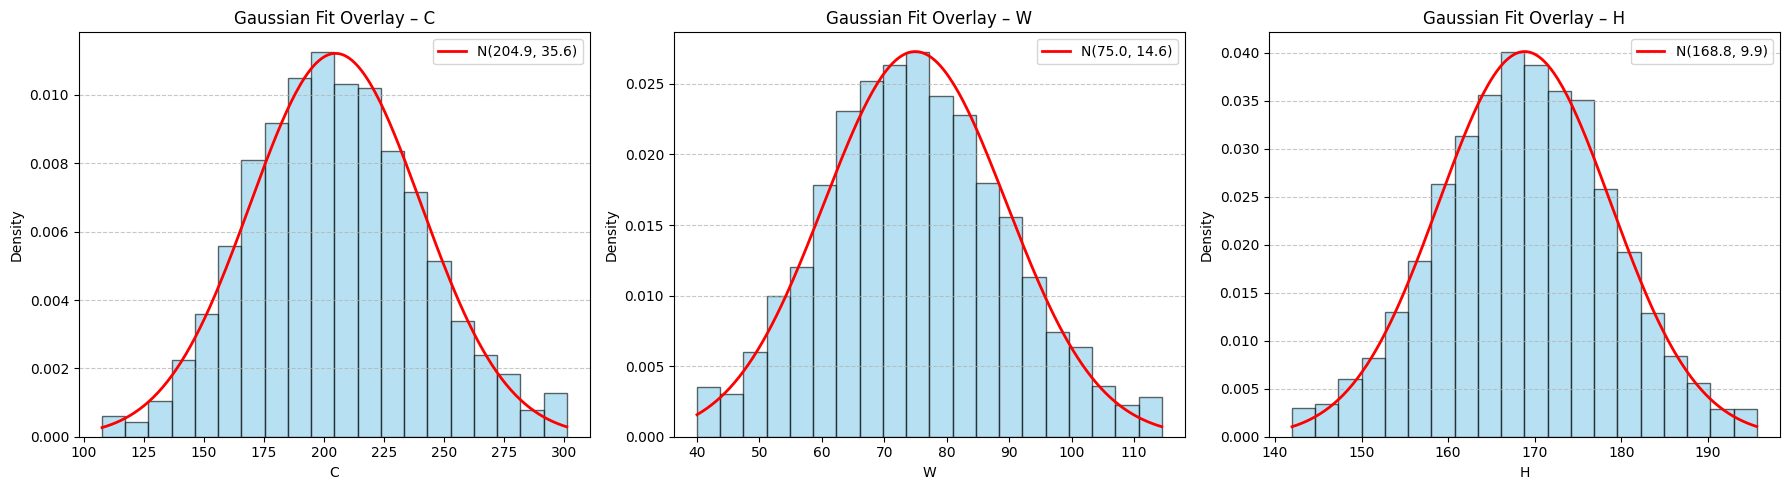

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    data = df[col]
    mu, sigma = data.mean(), data.std(ddof=1)

    x = np.linspace(data.min(), data.max(), 200)
    y = stats.norm.pdf(x, mu, sigma)

    ax = axes[i]

    ax.hist(data, bins=20, density=True, alpha=0.6,
            color='skyblue', edgecolor='black')

    # Overlay Gaussian curve
    ax.plot(x, y, color='red', linewidth=2, label=f'N({mu:.1f}, {sigma:.1f})')

    ax.set_title(f'Gaussian Fit Overlay – {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()


In [20]:
pairs_Variable = [('C', 'W'), ('C', 'H'), ('W', 'H')]
for x, y in pairs_Variable :
    cov = df[[x, y]].cov().iloc[0, 1]
    corr = df[[x, y]].corr().iloc[0, 1]

    print(f"Pair ({x}, {y}):")
    print(f"  Covariance: {cov:.3f}")
    print(f"  Correlation coefficient: {corr:.3f}")
    print("-" * 40)

Pair (C, W):
  Covariance: 84.403
  Correlation coefficient: 0.162
----------------------------------------
Pair (C, H):
  Covariance: -15.116
  Correlation coefficient: -0.043
----------------------------------------
Pair (W, H):
  Covariance: -7.892
  Correlation coefficient: -0.054
----------------------------------------


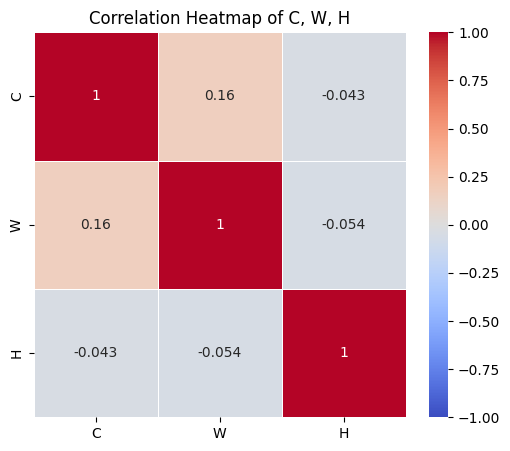

In [21]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Correlation Heatmap of C, W, H')
plt.show()

# **Comments**
All correlation coefficients are close to zero, which indicates a very weak relationship

1.   All correlation coefficients are close to zero, which indicates a very weak or no linear relationship among the variables.

2. The strongest correlation observed is C & W (0.162), but even this is considered negligible in practical terms.


3. Negative correlations (C & H: -0.043, W & H: -0.054) are so small that they can be considered statistically insignificant, showing almost no linear trend.

Overall, these results suggest that cholesterol, weight, and height are largely independent in your dataset, at least in terms of linear relationships.

# **Redo for each class gender**

In [22]:
from scipy.stats import norm, skew, kurtosis

In [23]:
for val in df['G'].unique():
    print(f"Gender value: {val}")
    print(df[df['G']==val].head())

Gender value: 1
   G           H          W           C  D
0  1  161.220174  67.928450  206.674781  0
2  1  167.735211  69.237118  177.087169  0
3  1  173.673655  52.588865  250.254190  0
4  1  179.135846  70.906916  145.829378  0
6  1  184.926886  69.649403  172.761944  0
Gender value: 0
    G           H          W           C  D
1   0  161.731196  77.664126  183.204176  0
5   0  161.968210  82.586370  212.018514  0
9   0  162.527883  69.684870  165.896972  0
14  0  170.669907  83.052525  160.406785  0
16  0  154.374541  73.277421  254.690489  0


In [24]:
def pmf_normal(data, bins):
    counts, edges = np.histogram(data, bins=bins)
    probs = counts / counts.sum()
    centers = 0.5 * (edges[1:] + edges[:-1])
    width = edges[1] - edges[0]
    return centers, probs, width, edges

In [25]:
def plot_row_pmf(df_subset, bins=10, suptitle=""):
    """Row of PMFs for C, W, H (relative-frequency)."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, col in enumerate(num_cols):
        data = df_subset[col].values
        centers, probs, width, _ = pmf_normal(data, bins)
        ax = axes[i]
        ax.bar(centers, probs, width=width, color='skyblue', edgecolor='black', alpha=0.8)
        ax.set_title(f'PMF of {col} ({bins} bins)')
        ax.set_xlabel(col); ax.set_ylabel('Probability')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        # sanity print
        print(f"{suptitle} {col} – sum(prob) = {probs.sum():.4f}")
    fig.suptitle(suptitle + " – PMFs", y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()


In [26]:
def plot_row_cdf(df_subset, suptitle=""):
    """Row of CDF for C, W, H."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, col in enumerate(num_cols):
        x = np.sort(df_subset[col].values)
        n = len(x)
        y = np.arange(1, n+1) / n
        ax = axes[i]
        ax.plot(x, y, linewidth=1.8)
        ax.set_title(f'CDF of {col}')
        ax.set_xlabel(col); ax.set_ylabel('Cumulative Probability')
        ax.grid(True, linestyle='--', alpha=0.7)
    fig.suptitle(suptitle + " – CDFs", y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()

In [27]:
bin_sets = [10, 15, 20]
def plot_grid_binwidths(df_subset, suptitle=""):
    """3x3 grid: rows = C/W/H, cols = bins 10/15/20 (PMF)."""
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    for i, col in enumerate(num_cols):
        data = df_subset[col].values
        for j, b in enumerate(bin_sets):
            centers, probs, width, _ = pmf_normal(data, b)
            ax = axes[i, j]
            ax.bar(centers, probs, width=width, color='orange', edgecolor='black', alpha=0.75)
            ax.set_title(f'{col} – {b} bins', fontsize=11)
            ax.set_xlabel(col); ax.set_ylabel('Probability')
            ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig.suptitle(suptitle + " – Bin-width comparison (PMF)", y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()


In [28]:
def print_descriptive(df_subset, title=""):
    """Mean, variance, skewness, kurtosis."""
    print(f"\n{title} – Descriptive Statistics")
    print("-"*60)
    for col in num_cols:
        s = df_subset[col].values
        stats_dict = {
            'Mean'     : np.mean(s),
            'Variance' : np.var(s, ddof=1),
            'Skewness' : skew(s, bias=False),
            'Kurtosis' : kurtosis(s, fisher=True, bias=False)  # excess kurtosis
        }
        print(f"{col}: " + ", ".join([f"{k}={v:.4f}" for k,v in stats_dict.items()]))
    print("-"*60)

In [29]:
def plot_row_gaussian_overlays(df_subset, bins=20, suptitle=""):
    """Row of density histograms with Gaussian overlays."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, col in enumerate(num_cols):
        data = df_subset[col].values
        mu, sigma = data.mean(), data.std(ddof=1)
        x = np.linspace(data.min(), data.max(), 400)
        y = norm.pdf(x, mu, sigma)

        ax = axes[i]
        ax.hist(data, bins=bins, density=True, alpha=0.6, color='skyblue', edgecolor='black')
        ax.plot(x, y, color='red', linewidth=2, label=f'N({mu:.2f}, {sigma:.2f})')
        ax.set_title(f'Gaussian Overlay – {col}')
        ax.set_xlabel(col); ax.set_ylabel('Density')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.legend()
    fig.suptitle(suptitle + " – Gaussian fits", y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()

In [30]:
def correlation_and_cov(df_subset, title=""):
    """Print Covariance & Correlation for (C,W), (C,H), (W,H) and a correlation heatmap """
    pairs = [('C','W'), ('C','H'), ('W','H')]
    print(f"\n{title} – ")
    print("-"*60)
    for a,b in pairs:
        cov = np.cov(df_subset[a].values, df_subset[b].values, ddof=1)[0,1]
        corr = np.corrcoef(df_subset[a].values, df_subset[b].values)[0,1]
        print(f"({a}, {b}): Cov={cov:.4f}, Corr={corr:.4f}")
    print("-"*60)

    # correlation heatmap
    corr_m = df_subset[num_cols].corr().values
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    cax = ax.imshow(corr_m, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(len(num_cols)))
    ax.set_xticklabels(num_cols)
    ax.set_yticks(range(len(num_cols)))
    ax.set_yticklabels(num_cols)
    ax.set_title(title + " – Correlation matrix")
    for (r, c), v in np.ndenumerate(corr_m):
      ax.text(c, r, f"{v:.2f}", ha='center', va='center',
            color='white' if abs(v) > 0.6 else 'black')
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [31]:
def comment_correlations(df_subset, title=""):
    pairs = [('C','W'), ('C','H'), ('W','H')]
    print(f"\n{title} – Correlation comments")
    for a,b in pairs:
        r = df_subset[[a,b]].corr().iloc[0,1]
        if abs(r) < 0.2:
            level = "very weak / none"
        elif abs(r) < 0.5:
            level = "weak"
        elif abs(r) < 0.8:
            level = "moderate"
        else:
            level = "strong"
        print(f"{a} vs {b}: r={r:.3f} → {level}")

Analysis functions that includes the 7 previous steps for both genders.

In [32]:
def analyze_gender(df_subset, label):
    # 1) PMFs (10 bins)
    plot_row_pmf(df_subset, bins=10, suptitle=f"{label}")
    # 2) CDFs
    plot_row_cdf(df_subset, suptitle=f"{label}")
    # 3) Bin-width comparison grid (10,15,20)
    plot_grid_binwidths(df_subset, suptitle=f"{label}")
    # 4) Descriptive stats
    print_descriptive(df_subset, title=f"{label}")
    # 5) Gaussian overlays
    plot_row_gaussian_overlays(df_subset, bins=20, suptitle=f"{label}")
    # 6) Covariance & correlation + matrix
    correlation_and_cov(df_subset, title=f"{label}")
    # 7) Narrative comments
    comment_correlations(df_subset, title=f"{label}")

Female Class C – sum(prob) = 1.0000
Female Class W – sum(prob) = 1.0000
Female Class H – sum(prob) = 1.0000


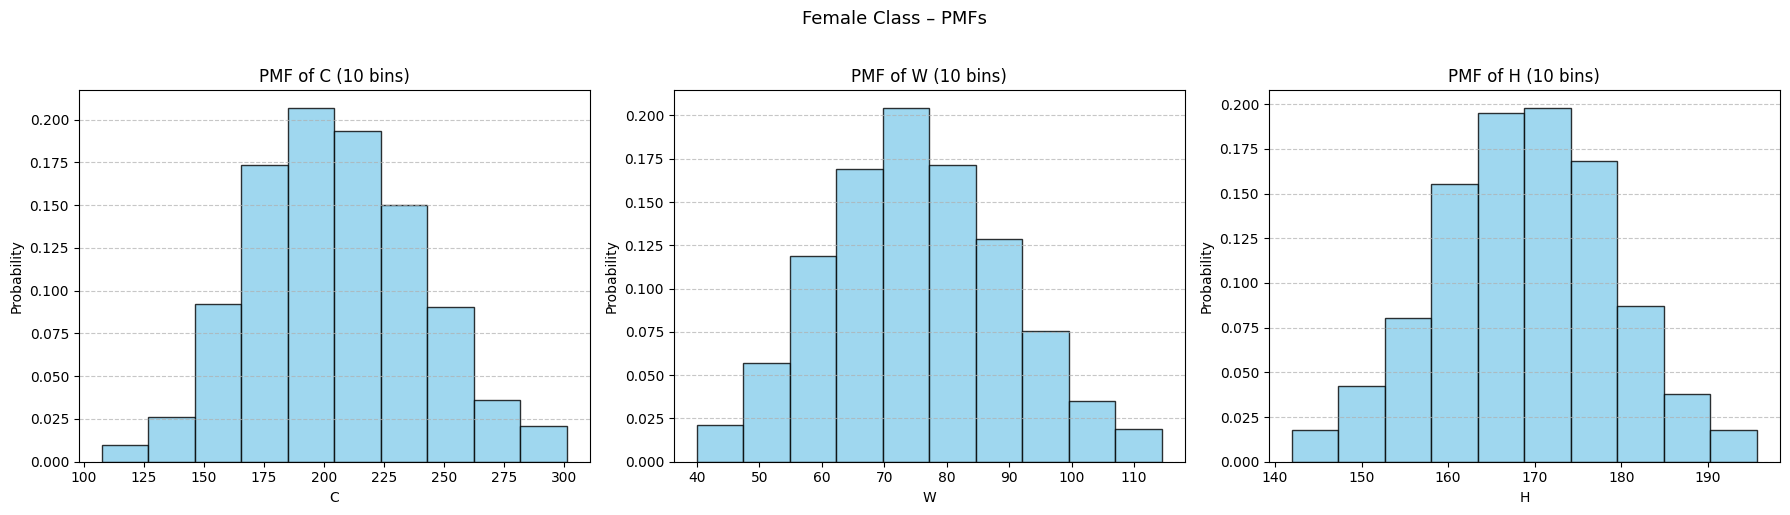

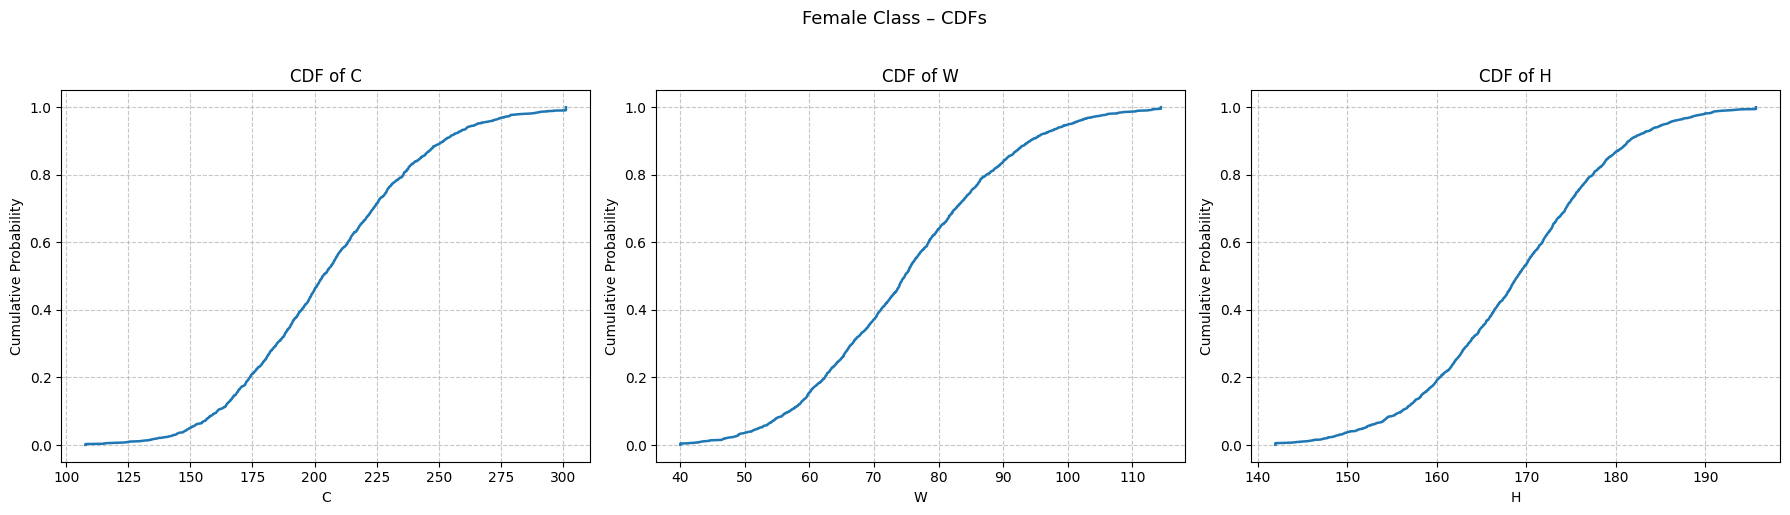

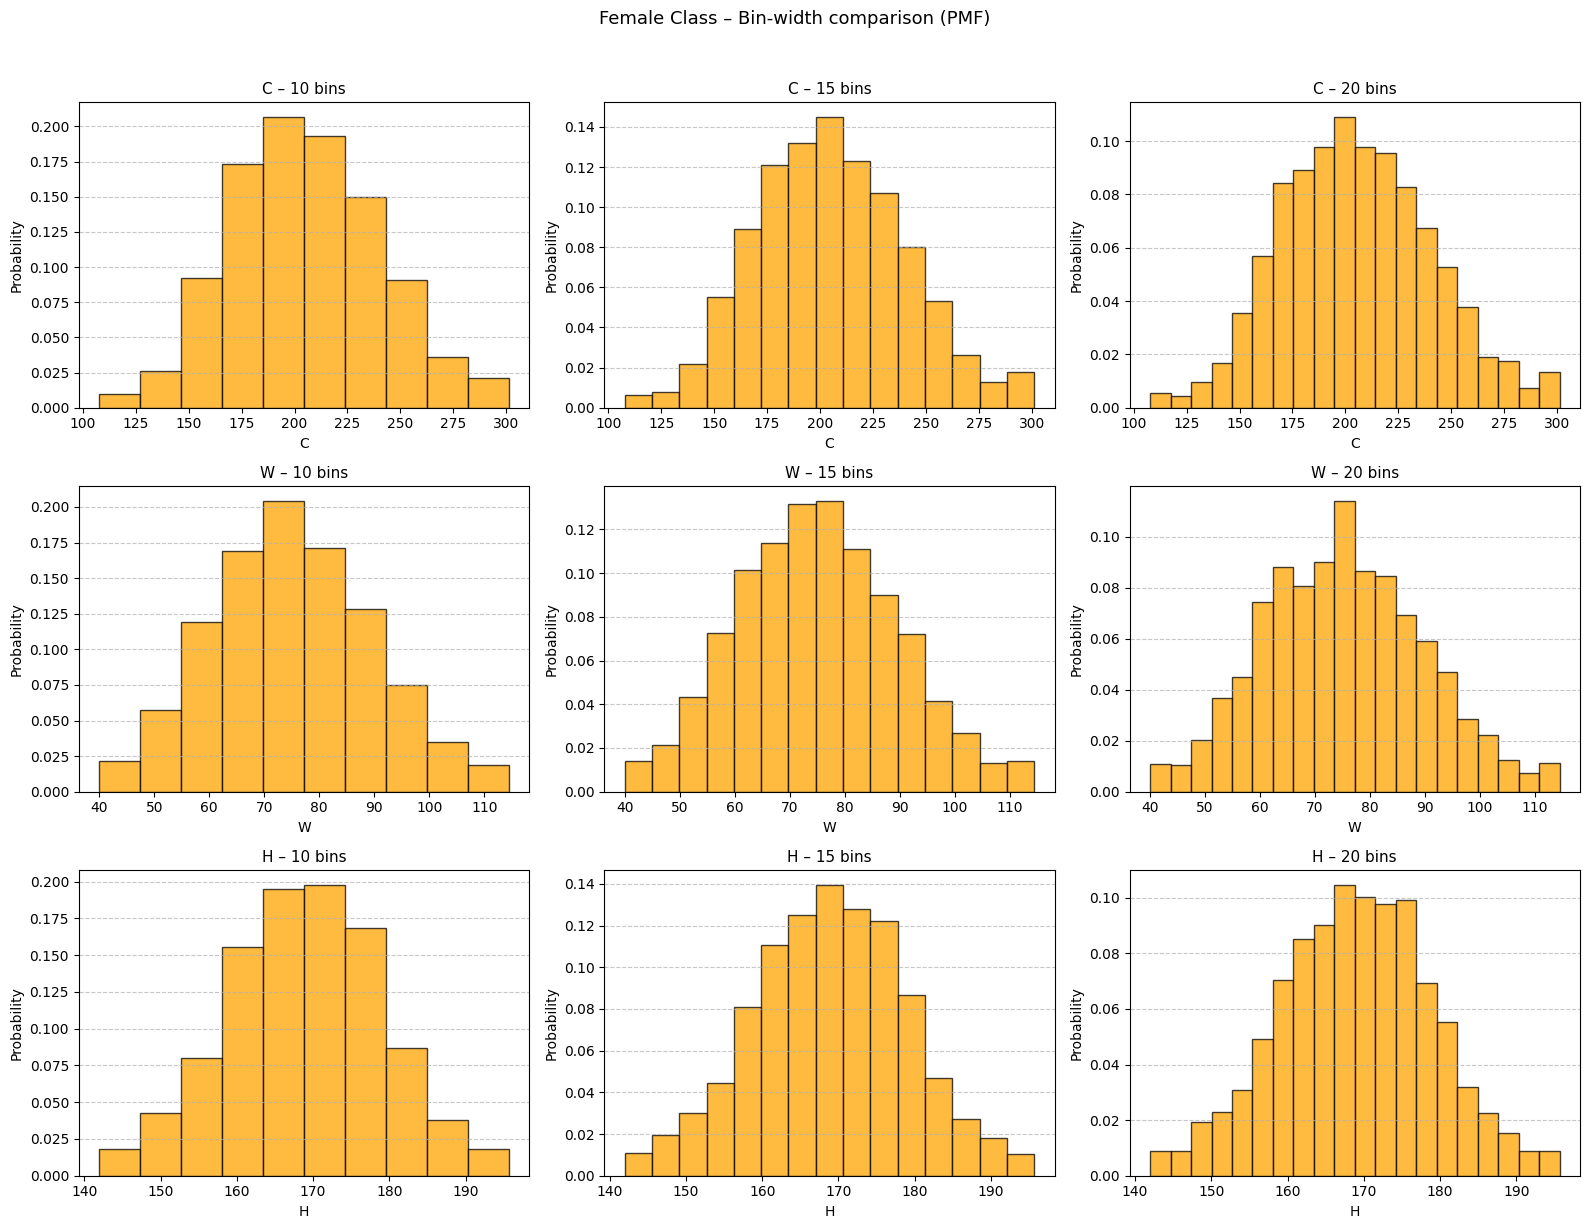


Female Class – Descriptive Statistics
------------------------------------------------------------
C: Mean=205.2263, Variance=1264.9942, Skewness=0.1925, Kurtosis=-0.1241
W: Mean=75.1779, Variance=211.7293, Skewness=0.1787, Kurtosis=-0.2555
H: Mean=168.9252, Variance=101.7516, Skewness=-0.0449, Kurtosis=-0.1303
------------------------------------------------------------


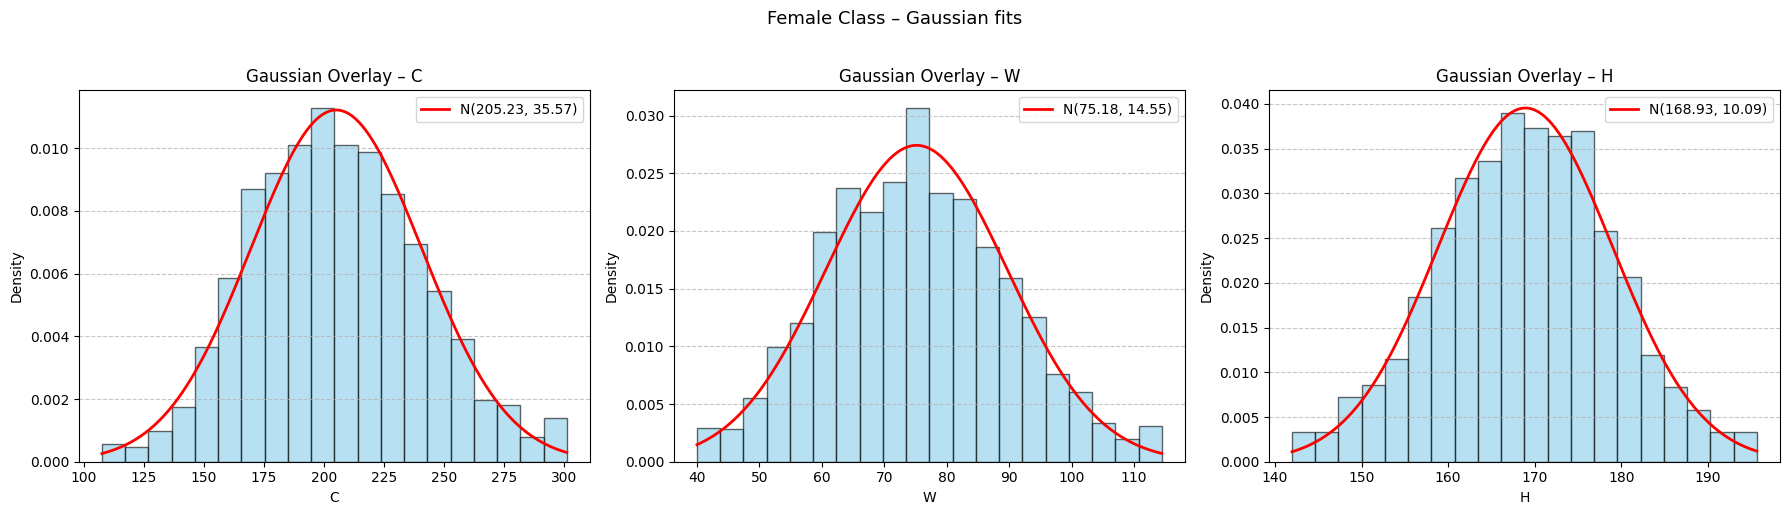


Female Class – 
------------------------------------------------------------
(C, W): Cov=88.6616, Corr=0.1713
(C, H): Cov=-21.5740, Corr=-0.0601
(W, H): Cov=-9.3514, Corr=-0.0637
------------------------------------------------------------

Female Class – Correlation comments
C vs W: r=0.171 → very weak / none
C vs H: r=-0.060 → very weak / none
W vs H: r=-0.064 → very weak / none


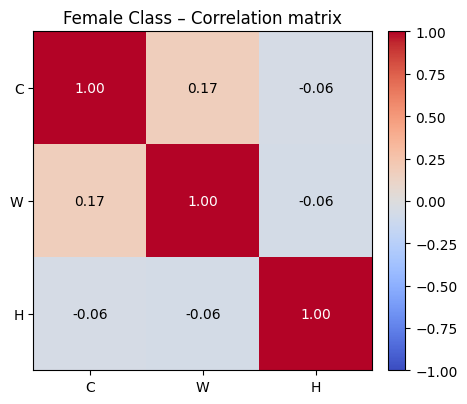

In [33]:
# Assuming LabelEncoder default: 0 = Female, 1 = Male
df_female = df[df['G'] == 0]
df_male   = df[df['G'] == 1]

analyze_gender(df_female, "Female Class")

Male Class C – sum(prob) = 1.0000
Male Class W – sum(prob) = 1.0000
Male Class H – sum(prob) = 1.0000


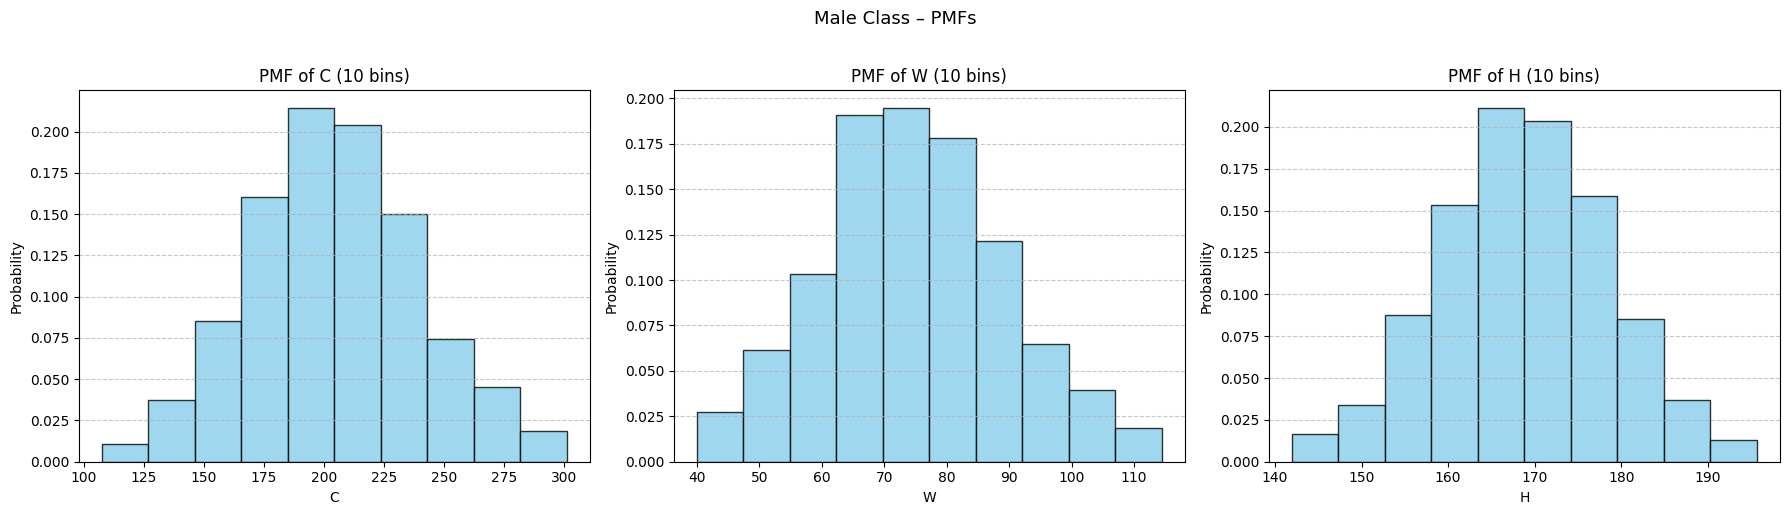

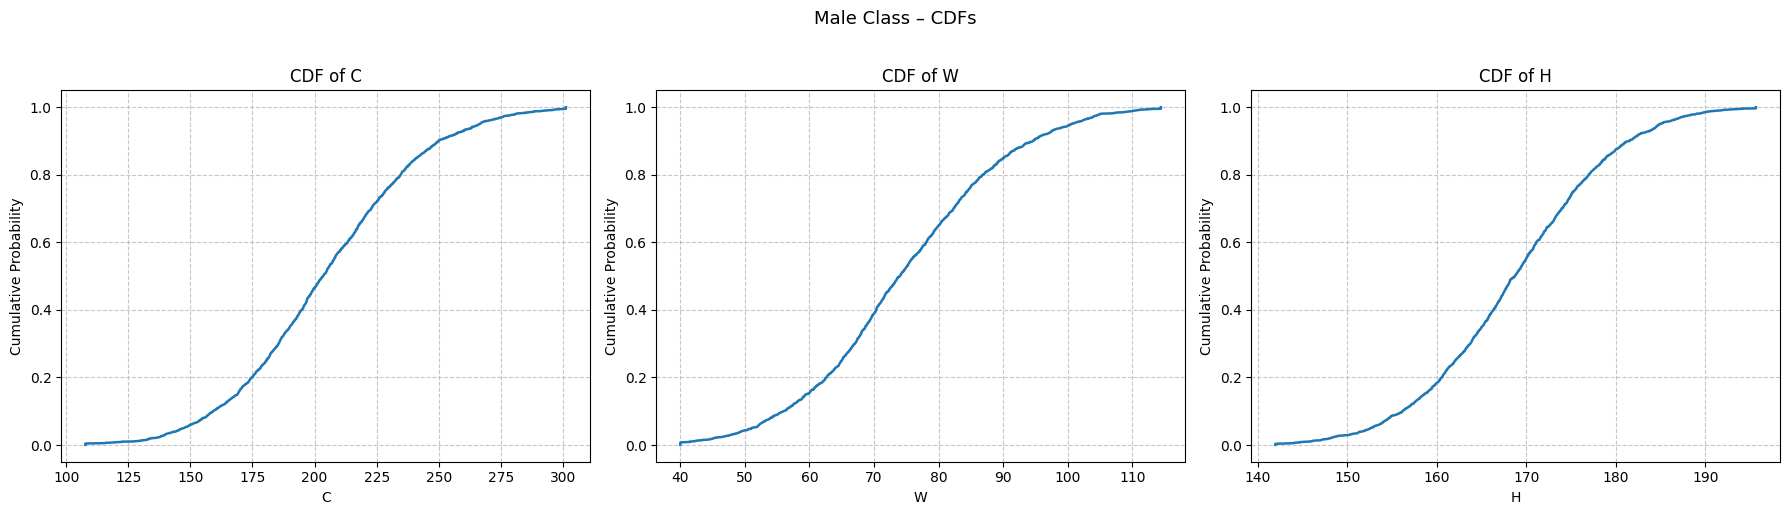

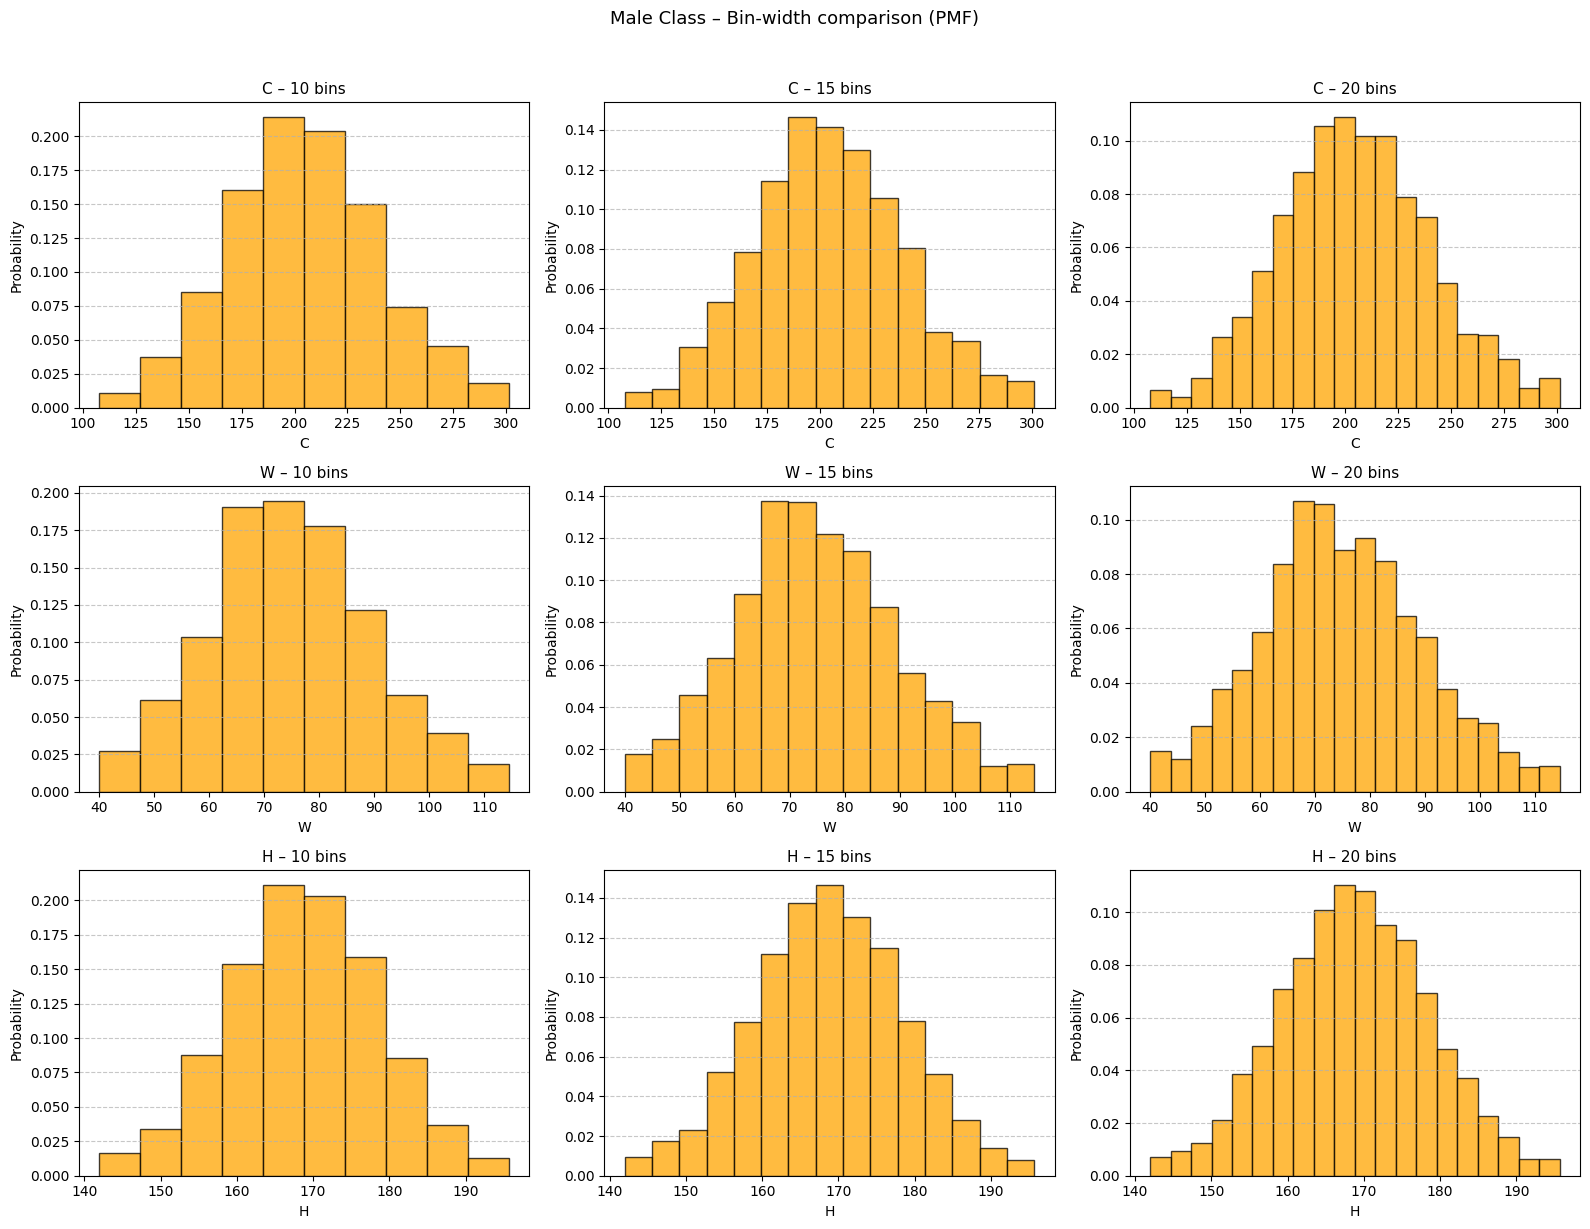


Male Class – Descriptive Statistics
------------------------------------------------------------
C: Mean=204.6663, Variance=1266.1156, Skewness=0.1250, Kurtosis=-0.0994
W: Mean=74.7513, Variance=215.5959, Skewness=0.1549, Kurtosis=-0.1976
H: Mean=168.7605, Variance=96.1541, Skewness=-0.0039, Kurtosis=-0.1330
------------------------------------------------------------


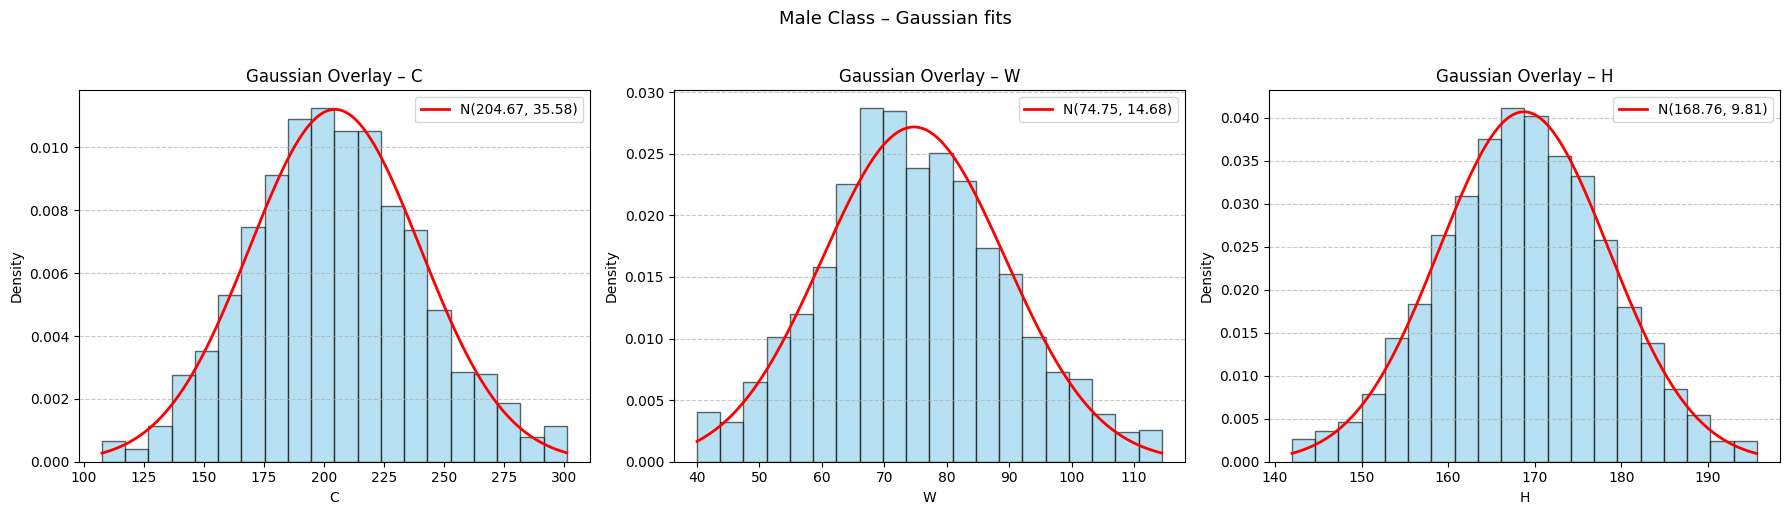


Male Class – 
------------------------------------------------------------
(C, W): Cov=80.0372, Corr=0.1532
(C, H): Cov=-8.6657, Corr=-0.0248
(W, H): Cov=-6.4613, Corr=-0.0449
------------------------------------------------------------

Male Class – Correlation comments
C vs W: r=0.153 → very weak / none
C vs H: r=-0.025 → very weak / none
W vs H: r=-0.045 → very weak / none


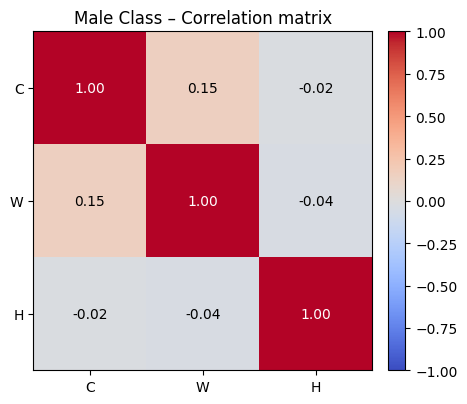

In [34]:
analyze_gender(df_male,   "Male Class")


##linear regression model to predict W from H, called WfH and computing the correlation coefficient between W and WfH.

In [35]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [36]:
X = df[['H']]
y = df['W']

model = LinearRegression()
model.fit(X, y)

df['WfH'] = model.predict(X)

# regression equation
print(f"Linear Regression Equation: WfH = {model.intercept_:.3f} + {model.coef_[0]:.3f} * H")

# Compute correlation coefficient between actual W and predicted WfH
corr_W_WfH = df['W'].corr(df['WfH'])
print(f"\nCorrelation coefficient between W and WfH: {corr_W_WfH:.4f}")

print("\nSample of predicted WfH values:")
print(df[['H', 'W', 'WfH']].head())


Linear Regression Equation: WfH = 88.432 + -0.080 * H

Correlation coefficient between W and WfH: 0.0543

Sample of predicted WfH values:
            H          W        WfH
0  161.220174  67.928450  75.573358
1  161.731196  77.664126  75.532598
2  167.735211  69.237118  75.053714
3  173.673655  52.588865  74.580061
4  179.135846  70.906916  74.144393


In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
# Model evaluation metrics
r2 = r2_score(y, df['WfH'])
mae = mean_absolute_error(y, df['WfH'])
rmse = np.sqrt(mean_squared_error(y, df['WfH']))

print("Model Performance Metrics: ")
print(f"R² Score : {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Model Performance Metrics: 
R² Score (Goodness of Fit): 0.0029
Mean Absolute Error (MAE): 11.7155
Root Mean Squared Error (RMSE): 14.5933


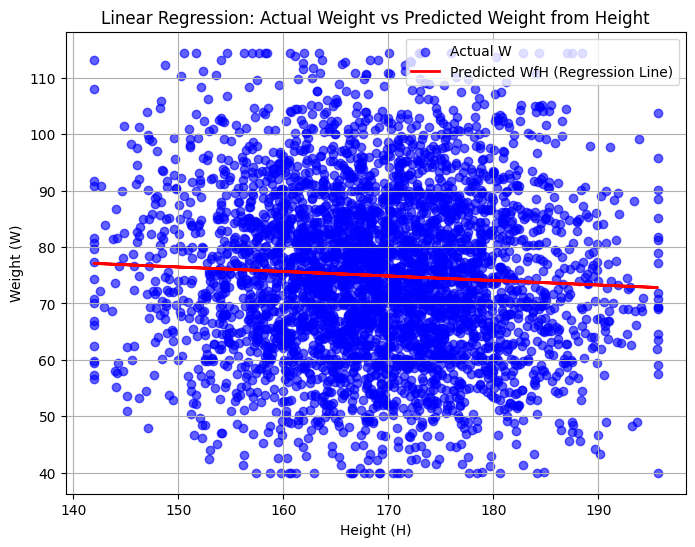

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(df['H'], df['W'], color='blue', label='Actual W', alpha=0.62)
plt.plot(df['H'], df['WfH'], color='red', label='Predicted WfH (Regression Line)', linewidth=2)
plt.xlabel('Height (H)')
plt.ylabel('Weight (W)')
plt.title('Linear Regression: Actual Weight vs Predicted Weight from Height')
plt.legend()
plt.grid(True)
plt.show()


##linear regression model to predict D from C, called DfC and computing the correlation coefficient between D and DfC.

In [40]:
X = df[['C']]
y = df['D']

model = LinearRegression()
model.fit(X, y)

df['DfC'] = model.predict(X)
print(f"Linear Regression Equation: DfC = {model.intercept_:.4f} + {model.coef_[0]:.4f} * C")

corr_D_DfC = df['D'].corr(df['DfC'])
print(f"\nCorrelation coefficient between D and DfC: {corr_D_DfC:.4f}")

print("\nSample of predicted values:")
print(df[['C', 'D', 'DfC']].head())


Linear Regression Equation: DfC = -0.7762 + 0.0062 * C

Correlation coefficient between D and DfC: 0.4429

Sample of predicted values:
            C  D       DfC
0  206.674781  0  0.510757
1  183.204176  0  0.364611
2  177.087169  0  0.326522
3  250.254190  0  0.782115
4  145.829378  0  0.131888


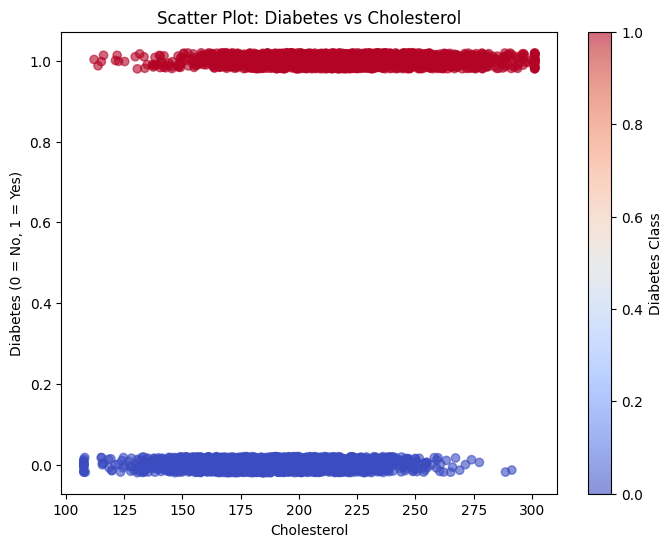

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(df['C'], df['D'] + np.random.uniform(-0.02, 0.02, size=len(df['D'])),
            c=df['D'], cmap='coolwarm', alpha=0.6)
plt.xlabel("Cholesterol")
plt.ylabel("Diabetes (0 = No, 1 = Yes)")
plt.title("Scatter Plot: Diabetes vs Cholesterol")
plt.colorbar(label="Diabetes Class")
plt.show()


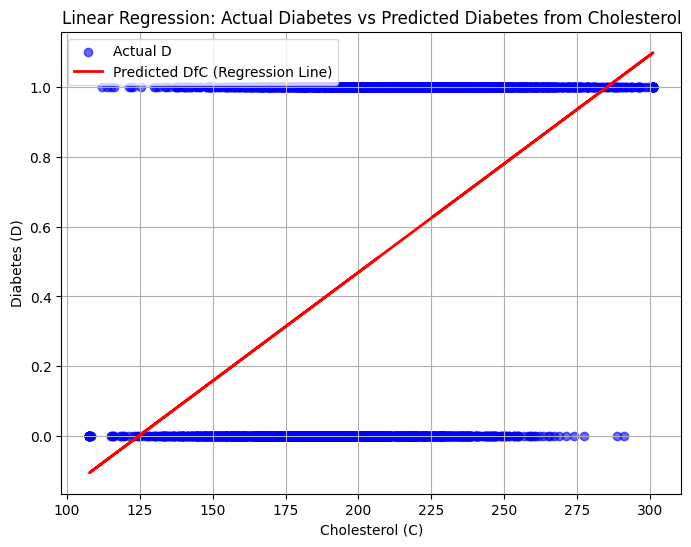

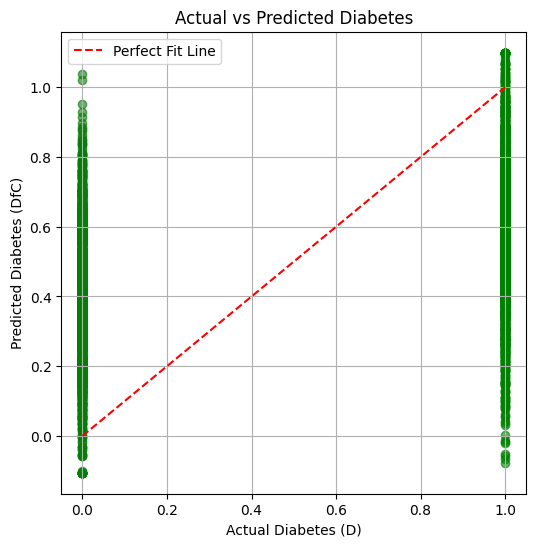

In [42]:
# Scatter Plot with Regression Line (C vs D)
plt.figure(figsize=(8,6))
plt.scatter(df['C'], df['D'], color='blue', label='Actual D', alpha=0.6)
plt.plot(df['C'], df['DfC'], color='red', label='Predicted DfC (Regression Line)', linewidth=2)
plt.xlabel('Cholesterol (C)')
plt.ylabel('Diabetes (D)')
plt.title('Linear Regression: Actual Diabetes vs Predicted Diabetes from Cholesterol')
plt.legend()
plt.grid(True)
plt.show()

#Actual vs Predicted Plot
plt.figure(figsize=(6,6))
plt.scatter(df['D'], df['DfC'], color='green', alpha=0.6)
plt.plot([df['D'].min(), df['D'].max()],
         [df['D'].min(), df['D'].max()],
         'r--', label='Perfect Fit Line')
plt.xlabel('Actual Diabetes (D)')
plt.ylabel('Predicted Diabetes (DfC)')
plt.title('Actual vs Predicted Diabetes')
plt.legend()
plt.grid(True)
plt.show()


## Use a machine learning model to predict D from the remaining variables.


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
# Features (independent variables)
X = df[['G', 'W', 'H', 'C']]
# Target (dependent variable)
y = df['D']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


- we will be using Gaussian Naive Bayes, a probabilistic classification model based on Bayes’ theorem with the assumption that each feature follows a normal (Gaussian) distribution.

In [45]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)


Naïve Bayes Model Accuracy: 0.7438


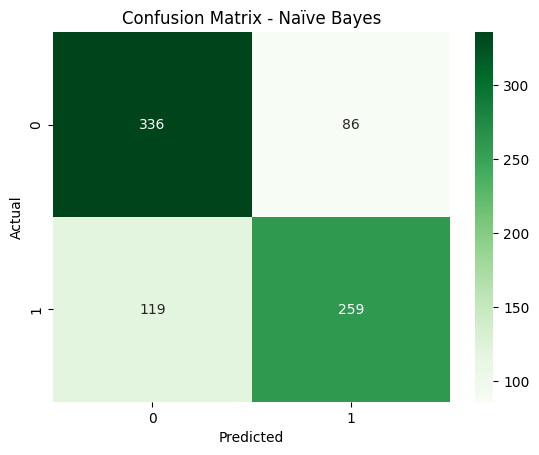


Classification Report - Naïve Bayes:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77       422
           1       0.75      0.69      0.72       378

    accuracy                           0.74       800
   macro avg       0.74      0.74      0.74       800
weighted avg       0.74      0.74      0.74       800



In [ ]:
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naïve Bayes Model Accuracy: {acc_nb:.4f}")

cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix  Naïve Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report Naïve Bayes:")
print(classification_report(y_test, y_pred_nb))